# Flow Matching: Equation of State Fitting

Fit van der Waals equation parameters $(a, b)$ from observed pressure data.

**Authors:** Victor Alves and John R. Kitchin

## System Information

This section documents the computational environment used to run this notebook.

In [1]:
import sys
import platform
import time
import psutil
import os

print("System Information")
print("=" * 70)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor()}")
print(f"CPU count: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
print(f"Total memory: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print("=" * 70)

# Key package versions
print("\nKey Library Versions:")
print("-" * 70)
packages = [
    ('numpy', 'np'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('sklearn', 'sklearn'),
    ('torch', 'torch'),
    ('gmr', 'gmr'),
]

for pkg_name, import_name in packages:
    try:
        mod = __import__(pkg_name)
        version = getattr(mod, '__version__', 'unknown')
        print(f"{pkg_name:<20} {version}")
    except ImportError:
        print(f"{pkg_name:<20} NOT INSTALLED")

print("-" * 70)

# Initialize timing and memory tracking
_start_time = time.time()
_process = psutil.Process(os.getpid())
_start_memory_mb = _process.memory_info().rss / (1024 * 1024)

print(f"\nNotebook execution started: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"Initial memory usage: {_start_memory_mb:.2f} MB")
print("=" * 70)

System Information
Python version: 3.12.8 (main, Jan 14 2025, 23:36:58) [Clang 19.1.6 ]
Platform: macOS-15.7.2-arm64-arm-64bit
Processor: arm
CPU count: 14 physical, 14 logical
Total memory: 64.00 GB

Key Library Versions:
----------------------------------------------------------------------
numpy                2.3.4
scipy                1.16.2
matplotlib           3.10.1


sklearn              1.7.2


torch                2.4.1
gmr                  2.0.2
----------------------------------------------------------------------

Notebook execution started: 2025-12-18 10:02:12
Initial memory usage: 320.38 MB


## System Information

This section documents the computational environment used to run this notebook.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import os

# Force CPU for JAX (must be set before importing JAX)
os.environ['JAX_PLATFORMS'] = 'cpu'

import torch

# Import reusable utilities from local module
from generative_optimization import (
    generate_samples,
    cluster_stats,
    ConditionalFlowMatching
)

# Force CPU for PyTorch
device = torch.device('cpu')
print(f"Using device: {device}")

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150

warnings.filterwarnings('ignore')

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


## Problem Setup

Van der Waals equation:
$$P = \frac{RT}{V - b} - \frac{a}{V^2}$$

Given pressure measurements at different $(V, T)$ conditions, estimate $(a, b)$.

In [3]:
# Van der Waals equation
R_gas = 8.314  # J/(mol·K)

def vdw_pressure(V, T, a, b):
    """Compute pressure from van der Waals equation."""
    return R_gas * T / (V - b) - a / V**2

# True parameters (for CO2-like gas)
a_true = 0.364  # Pa·m⁶/mol²
b_true = 4.27e-5  # m³/mol

print(f"True parameters: a = {a_true:.4f} Pa·m⁶/mol², b = {b_true:.2e} m³/mol")

True parameters: a = 0.3640 Pa·m⁶/mol², b = 4.27e-05 m³/mol


In [4]:
# Generate training data: sample (a, b) and compute pressures at representative conditions
n_samples = 3000
np.random.seed(42)

# Sample parameters around reasonable range
a_samples = np.random.uniform(0.1, 0.8, n_samples)
b_samples = np.random.uniform(1e-5, 1e-4, n_samples)

# Representative V, T values for computing pressures
V_repr = np.array([1.5e-4, 2.5e-4, 3.5e-4])  # m³/mol
T_repr = np.array([350, 400, 450])  # K

# Compute pressures for all parameter combinations
P_samples = []
for a, b in zip(a_samples, b_samples):
    P_vals = []
    for V, T in zip(V_repr, T_repr):
        try:
            P = vdw_pressure(V, T, a, b)
            P_vals.append(P / 1e6)  # Convert to MPa
        except:
            P_vals.append(np.nan)
    P_samples.append(P_vals)

P_samples = np.array(P_samples)

# Remove invalid samples (negative pressure, etc.)
valid = ~np.isnan(P_samples).any(axis=1) & (P_samples > 0).all(axis=1)
a_samples = a_samples[valid]
b_samples = b_samples[valid]
P_samples = P_samples[valid]

print(f"Valid samples: {len(a_samples)}")
print(f"P range: [{P_samples.min():.2f}, {P_samples.max():.2f}] MPa")

Valid samples: 2423
P range: [0.01, 53.17] MPa


In [5]:
# Train Flow Matching: generate [a, b] conditioned on [P1, P2, P3]
# Scale b by 1e4 for better numerical conditioning
x_data = np.column_stack([a_samples, b_samples * 1e4])  # Parameters to generate
c_data = P_samples  # Pressures to condition on

fm_eos = ConditionalFlowMatching(x_dim=2, c_dim=3, hidden_dim=128, n_layers=4)
losses = fm_eos.fit(x_data, c_data, epochs=1000, batch_size=64)

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

In [6]:
# Inverse problem: given observed pressures, find (a, b)
# Compute pressures at representative points using true parameters
P_obs = [vdw_pressure(V, T, a_true, b_true) / 1e6 for V, T in zip(V_repr, T_repr)]
print(f"Observed pressures (MPa): {[f'{p:.3f}' for p in P_obs]}")

# Sample parameters conditioned on observed pressures
samples = fm_eos.sample(c_values=[P_obs], n_samples=1000, n_steps=100)

# Unscale b
a_est = samples[:, 0]
b_est = samples[:, 1] * 1e-4

print(f"\nEstimated parameters:")
print(f"  a = {a_est.mean():.4f} ± {a_est.std():.4f} (true: {a_true:.4f})")
print(f"  b = {b_est.mean():.2e} ± {b_est.std():.2e} (true: {b_true:.2e})")

Observed pressures (MPa): ['10.942', '10.218', '9.203']

Estimated parameters:
  a = 0.3674 ± 0.0036 (true: 0.3640)
  b = 4.28e-05 ± 7.41e-07 (true: 4.27e-05)


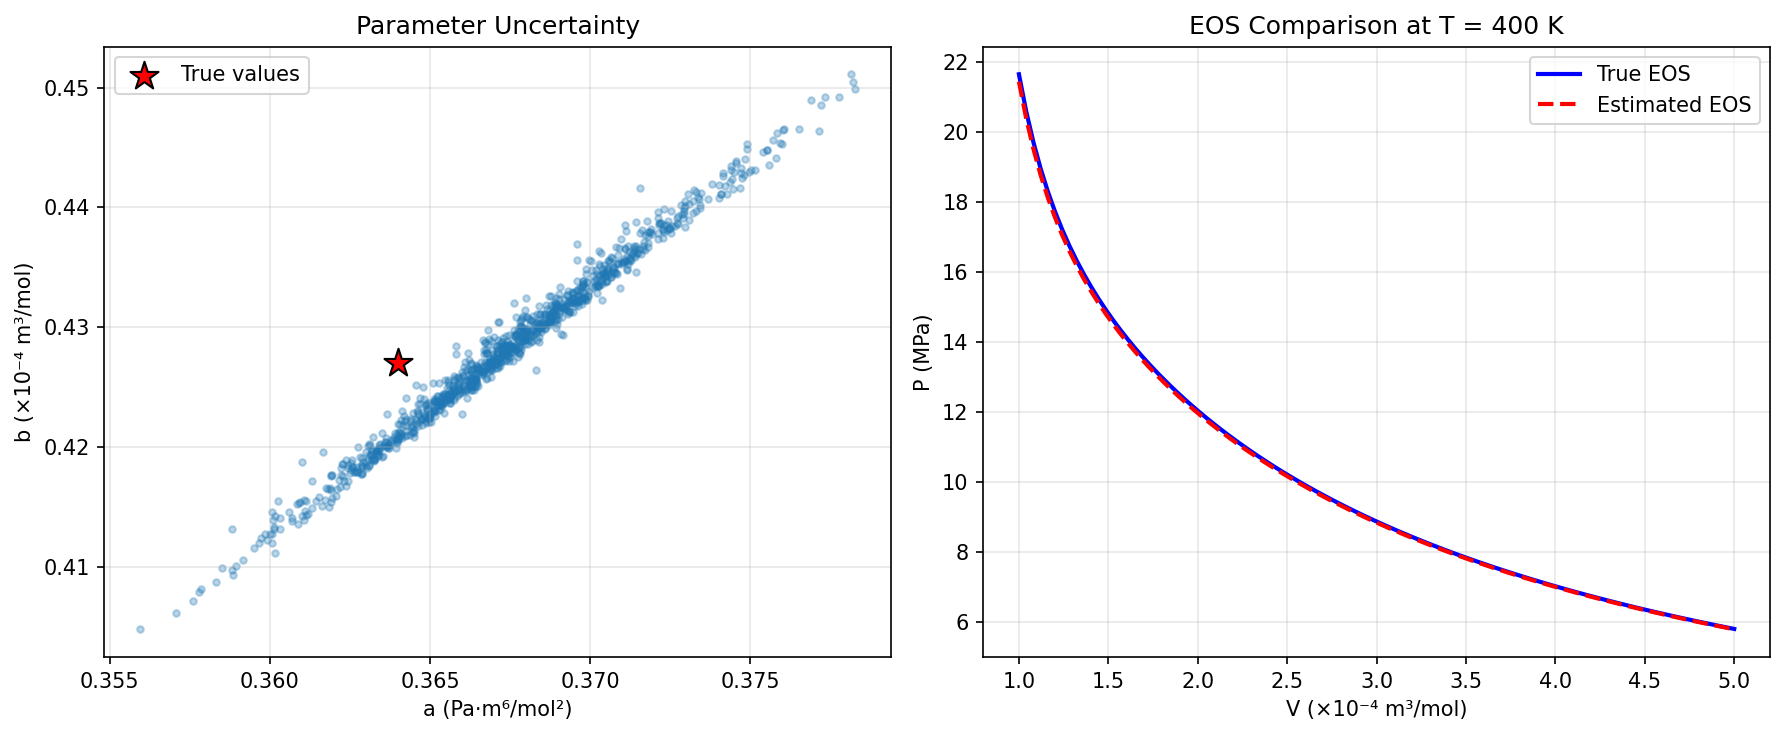

Mean absolute pressure error: 0.0532 MPa


In [7]:
# Visualize parameter uncertainty and verify fit
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Joint parameter distribution
axes[0].scatter(a_est, b_est * 1e4, alpha=0.3, s=10)
axes[0].scatter([a_true], [b_true * 1e4], c='red', s=200, marker='*',
                edgecolors='black', label='True values', zorder=5)
axes[0].set_xlabel('a (Pa·m⁶/mol²)')
axes[0].set_ylabel('b (×10⁻⁴ m³/mol)')
axes[0].set_title('Parameter Uncertainty')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Verify fit by comparing P-V curves
a_mean, b_mean = a_est.mean(), b_est.mean()
V_test = np.linspace(1e-4, 5e-4, 100)
T_test = 400  # K

P_true_curve = vdw_pressure(V_test, T_test, a_true, b_true) / 1e6
P_est_curve = vdw_pressure(V_test, T_test, a_mean, b_mean) / 1e6

axes[1].plot(V_test * 1e4, P_true_curve, 'b-', lw=2, label='True EOS')
axes[1].plot(V_test * 1e4, P_est_curve, 'r--', lw=2, label='Estimated EOS')
axes[1].set_xlabel('V (×10⁻⁴ m³/mol)')
axes[1].set_ylabel('P (MPa)')
axes[1].set_title(f'EOS Comparison at T = {T_test} K')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compute prediction error
P_error = np.abs(P_true_curve - P_est_curve).mean()
print(f"Mean absolute pressure error: {P_error:.4f} MPa")

In [8]:
# Final timing and memory report
_end_time = time.time()
_end_memory_mb = _process.memory_info().rss / (1024 * 1024)
_elapsed_seconds = _end_time - _start_time

print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION SUMMARY")
print("=" * 70)
print(f"Start time:      {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"End time:        {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_end_time))}")
print(f"Elapsed time:    {_elapsed_seconds:.2f} seconds ({_elapsed_seconds/60:.2f} minutes)")
print("-" * 70)
print(f"Initial memory:  {_start_memory_mb:.2f} MB")
print(f"Final memory:    {_end_memory_mb:.2f} MB")
print(f"Memory change:   {_end_memory_mb - _start_memory_mb:+.2f} MB")
print("=" * 70)


NOTEBOOK EXECUTION SUMMARY
Start time:      2025-12-18 10:02:12
End time:        2025-12-18 10:02:40
Elapsed time:    28.31 seconds (0.47 minutes)
----------------------------------------------------------------------
Initial memory:  320.38 MB
Final memory:    439.73 MB
Memory change:   +119.36 MB
